In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["True Species"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),True Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [4]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans.fit(X_scaled)

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [5]:
df["Predicted Cluster"] = kmeans.labels_

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),True Species,Predicted Cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,2
2,4.7,3.2,1.3,0.2,0,2
3,4.6,3.1,1.5,0.2,0,2
4,5.0,3.6,1.4,0.2,0,1


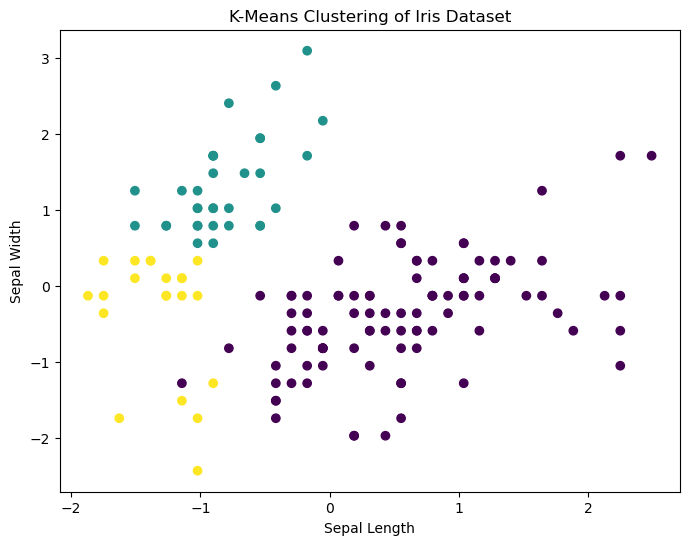

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=kmeans.labels_
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering of Iris Dataset")

plt.show()

In [7]:
comparison = pd.DataFrame({
    "True Label": y,
    "Predicted Cluster": kmeans.labels_
})

comparison.head(20)

,True Label,Predicted Cluster
0,0,1
1,0,2
2,0,2
3,0,2
4,0,1
5,0,1
6,0,1
7,0,1
8,0,2
9,0,2


In [8]:
print("Cluster Centers:")
print(kmeans.cluster_centers_)

Cluster Centers:
[[ 0.57100359 -0.37176778  0.69111943  0.66315198]
 [-0.81623084  1.31895771 -1.28683379 -1.2197118 ]
 [-1.32765367 -0.373138   -1.13723572 -1.11486192]]


In [9]:
print("Number of points in each cluster:")
print(df["Predicted Cluster"].value_counts().sort_index())

Number of points in each cluster:
Predicted Cluster
0    96
1    33
2    21
Name: count, dtype: int64
